In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Fetch Dataset directly from UCI Repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# Define the exact clinical columns based on medical documentation
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df = pd.read_csv(url, names=columns, na_values="?")

print("--- Initial Data Info ---")
print(df.info())

# 2. Rubric-Aligned Preprocessing (Handling Missing Values)
print("\n--- Missing Values Found Per Column ---")
print(df.isnull().sum())

# Justification Imputation (Median for continuous/ordinal variables)
# 'ca' and 'thal' have a few missing values in the Cleveland dataset
df['ca'] = df['ca'].fillna(df['ca'].median())
df['thal'] = df['thal'].fillna(df['thal'].median())

# Standardize the target variable (0 = Normal, 1-4 = Heart Disease presence)
# The original dataset has values 1,2,3,4 for degrees of disease. We binary-classify it.
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

print("\n--- Cleaned Data Sample ---")
print(df.head())

--- Initial Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB
None

--- Missing Values Found Per Column ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca  

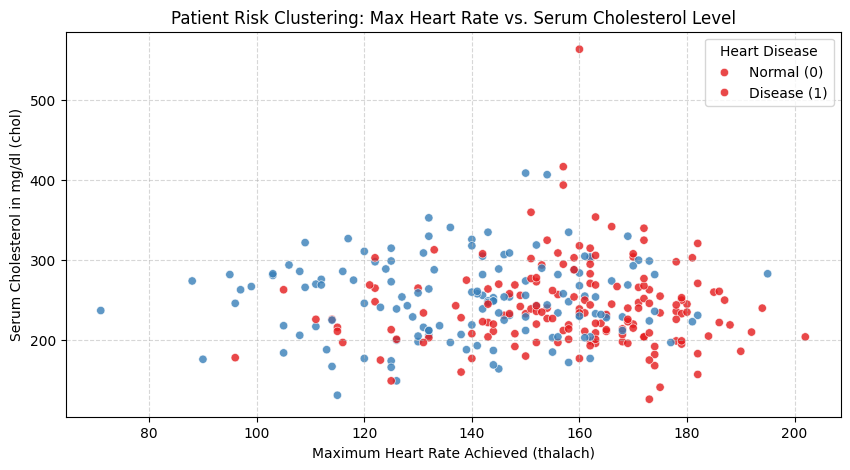

In [4]:
# 3. Exploratory Data Analysis Plot
plt.figure(figsize=(10, 5))

# Plotting Serum Cholesterol vs Max Heart Rate colored by Heart Disease Status
sns.scatterplot(data=df, x='thalach', y='chol', hue='target', palette='Set1', alpha=0.8)
plt.title('Patient Risk Clustering: Max Heart Rate vs. Serum Cholesterol Level')
plt.xlabel('Maximum Heart Rate Achieved (thalach)')
plt.ylabel('Serum Cholesterol in mg/dl (chol)')
plt.legend(title='Heart Disease', labels=['Normal (0)', 'Disease (1)'])
plt.grid(True, linestyle='--', alpha=0.5)

# Save the plot directly to use in your report
plt.savefig('eda_risk_scatter.png', dpi=300)
plt.show()

In [5]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# 1. Create a copy of the dataframe specifically for Apriori
apriori_df = pd.DataFrame()

# 2. Convert categorical variables to descriptive strings
apriori_df['Is_Male'] = df['sex'].map({1: 'Male', 0: 'Female'})
apriori_df['Chest_Pain'] = df['cp'].map({0: 'Typical_Angina', 1: 'Atypical_Angina', 2: 'Non_Anginal', 3: 'Asymptomatic'})
apriori_df['High_Fasting_Blood_Sugar'] = df['fbs'].map({1: 'FBS_High', 0: 'FBS_Normal'})
apriori_df['Heart_Disease'] = df['target'].map({1: 'Heart_Disease_Present', 0: 'Normal'})

# 3. Bin continuous variables into intuitive clinical ranges
apriori_df['Age_Group'] = pd.cut(df['age'], bins=[0, 45, 60, 100], labels=['Young', 'Middle-Aged', 'Senior'])
apriori_df['Blood_Pressure'] = pd.cut(df['trestbps'], bins=[0, 120, 140, 300], labels=['Normal_BP', 'Pre-Hypertension', 'Hypertension'])
apriori_df['Cholesterol'] = pd.cut(df['chol'], bins=[0, 200, 240, 600], labels=['Desirable_Chol', 'Borderline_Chol', 'High_Chol'])

# 4. One-Hot Encode the dataset (Convert text categories to 0 and 1 columns)
encoded_df = pd.get_dummies(apriori_df, dtype=bool)

# 5. Apply Apriori Algorithm (Find combinations that appear in at least 10% of patients)
frequent_itemsets = apriori(encoded_df, min_support=0.1, use_colnames=True)

# 6. Generate Association Rules using 'confidence' as our metric
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)

# 7. Filter rules where the outcome (consequent) is specifically 'Heart_Disease_Present'
clinical_rules = rules[rules['consequents'].apply(lambda x: 'Heart_Disease_Heart_Disease_Present' in str(x))]

# Sort by confidence to see the strongest combinations first
clinical_rules = clinical_rules.sort_values(by='confidence', ascending=False)

print(f"--- Successfully generated {len(clinical_rules)} clinical association rules ---")
print(clinical_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5))

--- Successfully generated 2 clinical association rules ---
                                           antecedents  \
131  frozenset({Age_Group_Middle-Aged, Cholesterol_...   
54         frozenset({Age_Group_Senior, Is_Male_Male})   

                                          consequents   support  confidence  \
131  frozenset({Heart_Disease_Heart_Disease_Present})  0.102310    0.720930   
54   frozenset({Heart_Disease_Heart_Disease_Present})  0.105611    0.711111   

         lift  
131  1.571524  
54   1.550120  


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Prepare Features (X) and Target (y) using the original data
# We drop 'target' from X.
X = df.drop(columns=['target'])
y = df['target']

# 2. Split data into Training (80%) and Testing (20%) sets to ensure fair validation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Scale the features (Crucial for Logistic Regression to interpret weights properly)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train the Logistic Regression Model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

# 5. Predict on test data
y_pred = log_reg.predict(X_test_scaled)

# 6. Print Evaluation Metrics
print("=== Model Performance ===")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.2%}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 7. Extract Feature Coefficients (The clinical weight of each symptom)
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient (Weight)': log_reg.coef_[0]
}).sort_values(by='Coefficient (Weight)', ascending=False)

print("=== Feature Importance (Clinical Impact) ===")
print(importance.to_string(index=False))

=== Model Performance ===
Overall Accuracy: 86.89%

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61

=== Feature Importance (Clinical Impact) ===
 Feature  Coefficient (Weight)
      ca              1.107898
    thal              0.677821
     sex              0.655563
      cp              0.543483
   exang              0.383642
   slope              0.354072
trestbps              0.313655
 restecg              0.217329
    chol              0.215375
 oldpeak              0.149953
     age             -0.103159
     fbs             -0.220560
 thalach             -0.348486


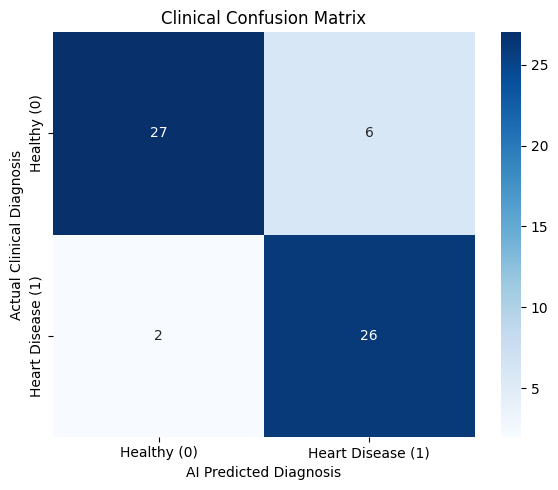

C:\Users\avien\AppData\Local\Temp\ipykernel_20788\2773742534.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, x='Coefficient (Weight)', y='Feature', palette='viridis')


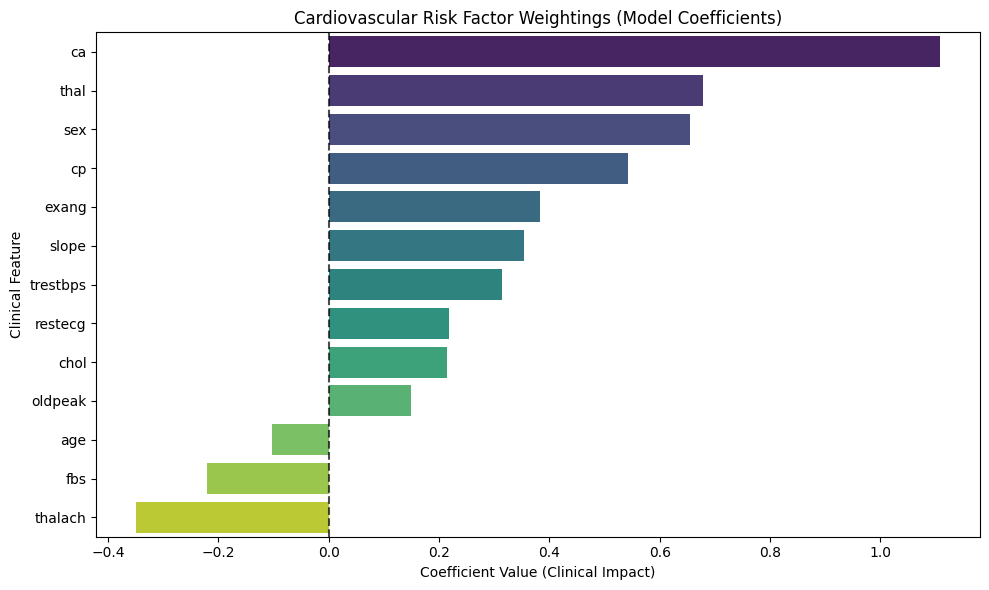

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generate and Visualise the Confusion Matrix (Essential for Report Section: Results)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Healthy (0)', 'Heart Disease (1)'],
            yticklabels=['Healthy (0)', 'Heart Disease (1)'])
plt.title('Clinical Confusion Matrix')
plt.ylabel('Actual Clinical Diagnosis')
plt.xlabel('AI Predicted Diagnosis')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

# 2. Visualise Feature Importance (Essential for Report Section: Proposed AI Concept)
plt.figure(figsize=(10, 6))
# Using the 'importance' dataframe created in the previous step
sns.barplot(data=importance, x='Coefficient (Weight)', y='Feature', palette='viridis')
plt.axvline(x=0, color='black', linestyle='--', alpha=0.7)
plt.title('Cardiovascular Risk Factor Weightings (Model Coefficients)')
plt.xlabel('Coefficient Value (Clinical Impact)')
plt.ylabel('Clinical Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()